In [2]:
# Setup -------------------------------------------------------------------
import pandas as pd
import numpy as np

# pip install statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols, glm
import matplotlib.pyplot as plt

# pip install seaborn
import seaborn as sns

# pip install scikit-learn
from sklearn.metrics import confusion_matrix



In [3]:
# Dataload ----------------------------------------------------------------
# Ensure the 'DonnerParty.csv' file is in the correct directory, as specified in the R script.
# The 'dtype' parameter is used to explicitly set column types, similar to 'col_types' in R.
try:
    donner_party = pd.read_csv("../../03-Database/DonnerParty.csv", dtype={
        'Age': np.float64,
        'Sex_Male': 'category',
        'Survived': 'category'
    })
    print(donner_party.head())
except FileNotFoundError:
    print("Error: DonnerParty.csv not found. Please check the file path.")

    Age Sex_Male Survived
0  23.0     Male       No
1  40.0   Female      Yes
2  40.0     Male      Yes
3  30.0     Male       No
4  28.0     Male       No


In [4]:

# Convert 'Sex_Male' and 'Survived' to categorical types with specified levels,
# similar to the factor() function in R.
donner_party['Sex_Male'] = pd.Categorical(donner_party['Sex_Male'],
                                          categories=["Male", "Female"])
donner_party['Survived'] = pd.Categorical(donner_party['Survived'],
                                          categories=["No", "Yes"])

# Marginal distributions --------------------------------------------------
# This replicates the table() function from R, creating a cross-tabulation.
# 'pd.crosstab' is a direct equivalent.
print("\nCross-tabulation of Survived vs. Sex_Male:")
cross_tab = pd.crosstab(donner_party['Survived'], donner_party['Sex_Male'])
print(cross_tab)


Cross-tabulation of Survived vs. Sex_Male:
Sex_Male  Male  Female
Survived              
No          20       5
Yes         10      10


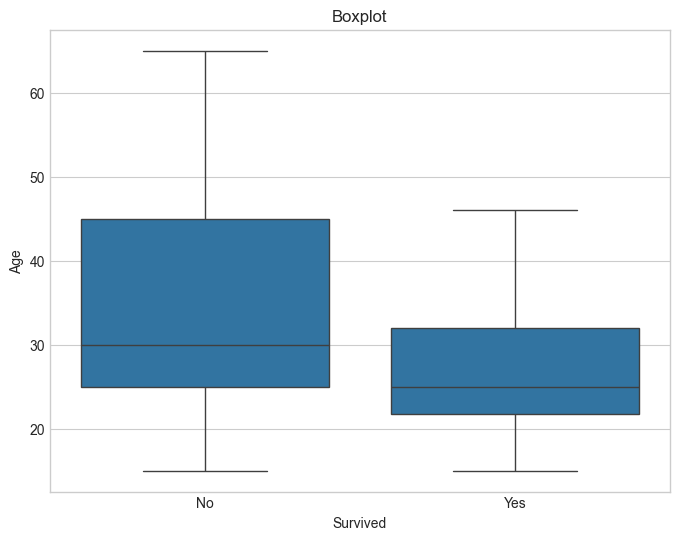

In [5]:
# Plotting with matplotlib and seaborn
# This section reproduces the boxplot created by ggplot in R.
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 6))
sns.boxplot(x='Survived', y='Age', data=donner_party)
plt.title("Boxplot")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()

In [5]:
donner_party.describe(include='all')

,Age,Sex_Male,Survived
count,45.000000,45,45
unique,NaN,2,2
top,NaN,Male,No
freq,NaN,30,25
mean,31.800000,NaN,NaN
std,12.511086,NaN,NaN
min,15.000000,NaN,NaN
25%,24.000000,NaN,NaN
50%,28.000000,NaN,NaN
75%,40.000000,NaN,NaN


In [6]:
# Linear OLS Model -------------------------------------------------------
# In Python, we need to manually create a dummy variable for the 'Survived' column.
donner_party['Survived'] = donner_party['Survived'].apply(lambda x: 1 if x == 'Yes' else 0).astype(float)
donner_party['Sex_Male'] = donner_party['Sex_Male'].apply(lambda x: 1 if x == 'Male' else 0).astype(float)

# Use 'ols' from statsmodels to fit the linear regression model.
# The formula syntax is similar to R's.
ols_mdl = ols('Survived ~ Age', data=donner_party).fit()
print("\nOLS Model Summary:")
print(ols_mdl.summary())


OLS Model Summary:
                            OLS Regression Results                            
Dep. Variable:               Survived   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     5.347
Date:                Thu, 04 Sep 2025   Prob (F-statistic):             0.0256
Time:                        20:51:06   Log-Likelihood:                -29.744
No. Observations:                  45   AIC:                             63.49
Df Residuals:                      43   BIC:                             67.10
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8692      0.197

In [7]:
# Calculate confidence intervals, similar to confint() in R.
ci_ols_mdl = ols_mdl.conf_int(alpha=0.05)
print("\nConfidence intervals for OLS model:")
print(ci_ols_mdl)



Confidence intervals for OLS model:
                  0         1
Intercept  0.471729  1.266736
Age       -0.025008 -0.001709


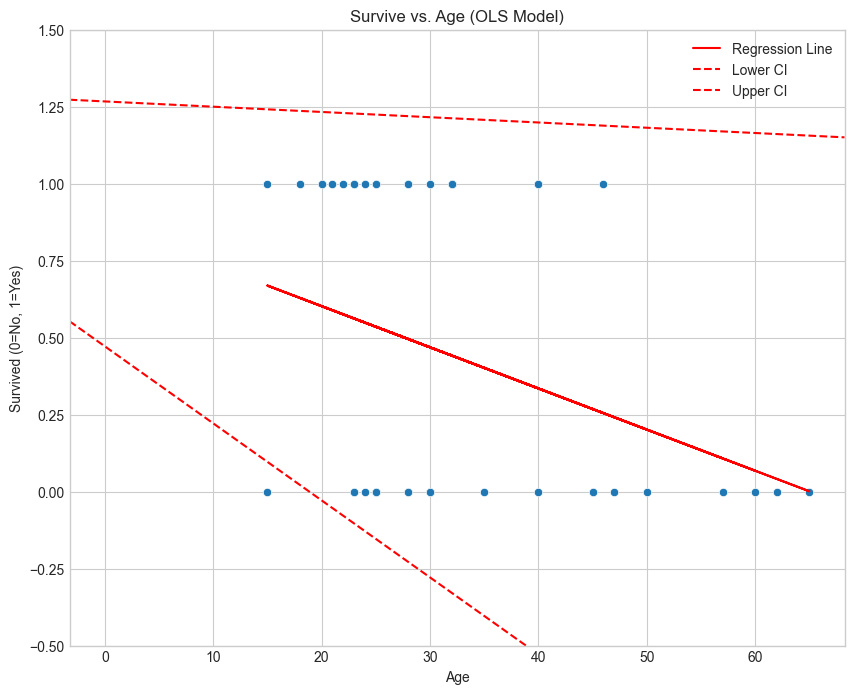

In [8]:
# Add residuals to the DataFrame.
donner_party['Ols_res'] = ols_mdl.resid

# Plotting the regression line and confidence intervals.
# This part recreates g2 from the R script.
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Age', y='Survived', data=donner_party)
# Plot the main regression line
plt.plot(donner_party['Age'], ols_mdl.fittedvalues, color='red', label='Regression Line')
# Plot confidence interval lines for the slope
intercept_ci = ols_mdl.conf_int().loc['Intercept']
age_ci = ols_mdl.conf_int().loc['Age']
plt.axline(xy1=(0, intercept_ci[0]), slope=age_ci[0], linestyle='--', color='red', label='Lower CI')
plt.axline(xy1=(0, intercept_ci[1]), slope=age_ci[1], linestyle='--', color='red', label='Upper CI')
plt.title("Survive vs. Age (OLS Model)")
plt.xlabel("Age")
plt.ylabel("Survived (0=No, 1=Yes)")
plt.ylim(-0.5, 1.5)
plt.legend()
plt.show()

<Figure size 800x600 with 0 Axes>

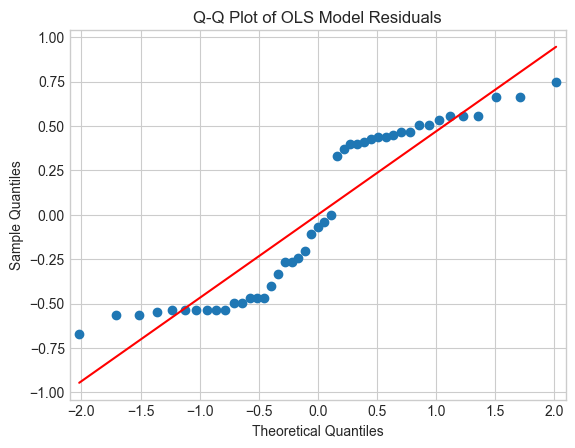

In [9]:

# Q-Q plots for residuals
# This reproduces the Q-Q plot diagnostics.
plt.figure(figsize=(8, 6))
sm.qqplot(ols_mdl.resid, line='s')
plt.title("Q-Q Plot of OLS Model Residuals")
plt.show()


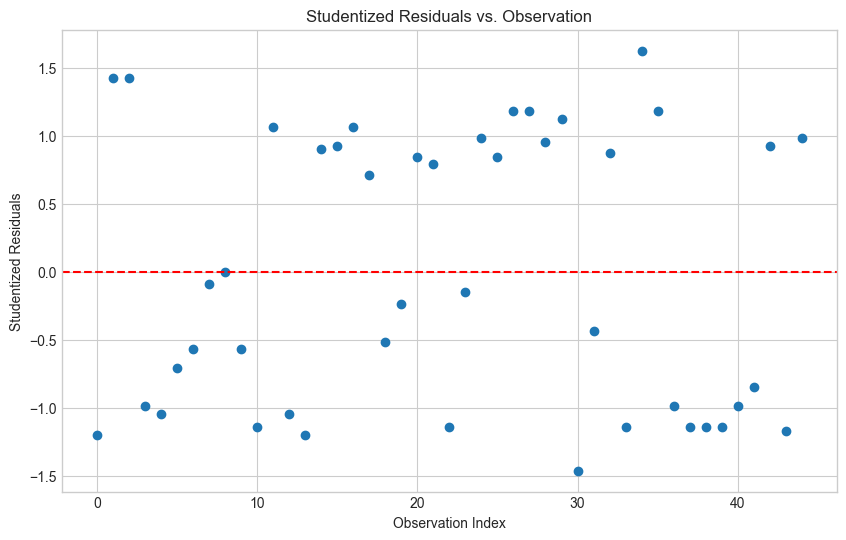

In [10]:
# Studentized residuals vs. Observation plot
# Python's 'statsmodels' can compute studentized residuals
# and this plot helps check for outliers and influential points.
studentized_residuals = ols_mdl.get_influence().resid_studentized_external
plt.figure(figsize=(10, 6))
plt.plot(studentized_residuals, 'o')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Studentized Residuals vs. Observation")
plt.xlabel("Observation Index")
plt.ylabel("Studentized Residuals")
plt.show()

In [11]:
# Fitting logistic regression: survive~age --------------------------------
# Use 'glm' from statsmodels with the 'binomial' family.
# This directly translates the 'glm' function call from R.
logit_mdl = glm('Survived ~ Age', data=donner_party, family=sm.families.Binomial()).fit()
print("\nLogistic Regression Model (Age) Summary:")
print(logit_mdl.summary())


Logistic Regression Model (Age) Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:               Survived   No. Observations:                   45
Model:                            GLM   Df Residuals:                       43
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28.145
Date:                Wed, 03 Sep 2025   Deviance:                       56.291
Time:                        17:26:18   Pearson chi2:                     43.2
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1158
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept 

In [12]:

# Get coefficients and odds ratio, similar to R's exp(coefficients())
print("\nCoefficients:")
print(logit_mdl.params)
print("\nOdds Ratio for Age:")
print(np.exp(logit_mdl.params['Age']))


Coefficients:
Intercept    1.818518
Age         -0.066470
dtype: float64

Odds Ratio for Age:
0.9356907245143693


In [13]:
# Confidence intervals for parameters and odds ratios.
ci_logit_mdl = logit_mdl.conf_int()
print("\nConfidence intervals for Logistic Model parameters:")
print(ci_logit_mdl)
print("\nConfidence intervals for Logistic Model odds ratios:")
print(np.exp(ci_logit_mdl))



Confidence intervals for Logistic Model parameters:
                  0         1
Intercept -0.140215  3.777252
Age       -0.129620 -0.003320

Confidence intervals for Logistic Model odds ratios:
                  0          1
Intercept  0.869171  43.695804
Age        0.878429   0.996685


<Figure size 800x600 with 0 Axes>

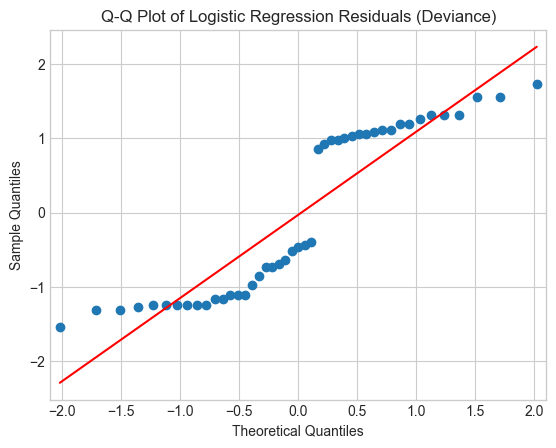

In [14]:

# Diagnostic plots (Q-Q plot for residuals)
# The Q-Q plot for residuals in a logistic regression model is not as
# straightforward as in linear regression. This code provides a similar
# plot for reference, though interpretation can be more complex.
plt.figure( figsize = (8, 6))
sm.qqplot(logit_mdl.resid_deviance, line='s')
plt.title("Q-Q Plot of Logistic Regression Residuals (Deviance)")
plt.show()


In [15]:
# Fitting logistic regression: survive~age+sex ----------------------------
# The '+' operator in the formula adds another predictor.
logit2_mdl = glm('Survived ~ Age + Sex_Male', data=donner_party, family=sm.families.Binomial()).fit()
print("\nLogistic Regression Model (Age + Sex) Summary:")
print(logit2_mdl.summary())
print("\nConfidence intervals for Logistic Model (Age + Sex) parameters:")
print(logit2_mdl.conf_int())



Logistic Regression Model (Age + Sex) Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:               Survived   No. Observations:                   45
Model:                            GLM   Df Residuals:                       42
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -25.628
Date:                Wed, 03 Sep 2025   Deviance:                       51.256
Time:                        17:26:19   Pearson chi2:                     44.4
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2093
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Inte

<Figure size 800x600 with 0 Axes>

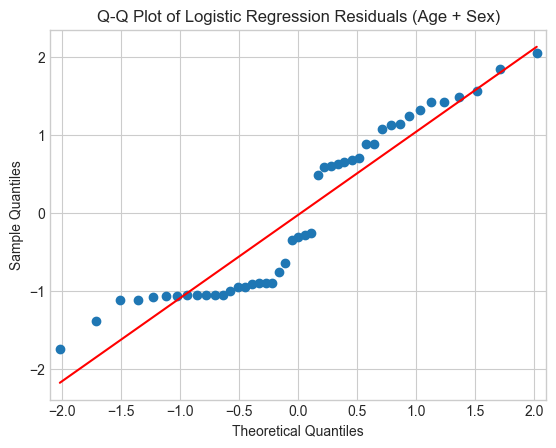

In [16]:
# Q-Q plot for residuals of the second model.
plt.figure(figsize=(8, 6))
sm.qqplot(logit2_mdl.resid_deviance, line='s')
plt.title("Q-Q Plot of Logistic Regression Residuals (Age + Sex)")
plt.show()


In [17]:
# Fitting logistic regression: survive~age+sex+age*sex --------------------
# The '*' operator in the formula automatically includes the main effects
# and the interaction term, just like in R.
logit3_mdl = glm('Survived ~ Age * Sex_Male', data=donner_party, family=sm.families.Binomial()).fit()
print("\nLogistic Regression Model (Age * Sex) Summary:")
print(logit3_mdl.summary())
print("\nConfidence intervals for Logistic Model (Age * Sex) parameters:")
print(logit3_mdl.conf_int())


Logistic Regression Model (Age * Sex) Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:               Survived   No. Observations:                   45
Model:                            GLM   Df Residuals:                       41
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -23.673
Date:                Wed, 03 Sep 2025   Deviance:                       47.346
Time:                        17:26:19   Pearson chi2:                     43.9
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2751
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------


<Figure size 800x600 with 0 Axes>

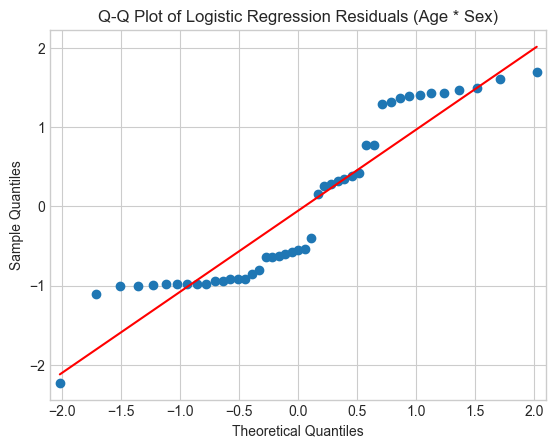

In [18]:
# Q-Q plot for residuals of the third model.
plt.figure(figsize=(8, 6))
sm.qqplot(logit3_mdl.resid_deviance, line='s')
plt.title("Q-Q Plot of Logistic Regression Residuals (Age * Sex)")
plt.show()

In [19]:
logit3_mdl.fittedvalues

0     0.394451
1     0.373652
2     0.272742
3     0.341643
4     0.356399
5     0.272742
6     0.184380
7     0.155086
8     0.142744
9     0.184380
10    0.916409
11    0.356399
12    0.356399
13    0.394451
14    0.951513
15    0.941733
16    0.356399
17    0.987071
18    0.132953
19    0.177574
20    0.966589
21    0.433827
22    0.379047
23    0.163789
24    0.379047
25    0.417946
26    0.327187
27    0.738080
28    0.930125
29    0.341643
30    0.457894
31    0.078905
32    0.959722
33    0.379047
34    0.235841
35    0.738080
36    0.341643
37    0.379047
38    0.379047
39    0.379047
40    0.341643
41    0.306110
42    0.394451
43    0.386720
44    0.916409
dtype: float64

In [20]:
# Confusion matrix ---------------------------------------------------------
# Create a confusion matrix to evaluate the model's performance.
# We first get the predicted probabilities, then threshold them at 0.5.
predicted_classes = (logit3_mdl.fittedvalues > 0.5).astype(int)
true_classes = (donner_party['Survived'] == 'Yes').astype(int)

In [21]:
# Use sklearn's confusion_matrix to generate the matrix.
conf_matrix = confusion_matrix(true_classes, predicted_classes)
print("\nConfusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[35 10]
 [ 0  0]]
